# Install & Import Library

In [2]:
%pip install torch
%pip install transformers
%pip install conllu
%pip install pandas numpy scikit-learn matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import conllu
import os
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
from collections import defaultdict




# Explore Dataset IndoLEM

## A. Explore Task Dataset - UD_Indonesian_GSD (RAW)

### 1. Set Path

In [3]:
BASE_PATH = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\raw\indolem-main\dependency_parsing"

PATH_GSD_TRAIN = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-train.conllu")
PATH_GSD_DEV   = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-dev.conllu")
PATH_GSD_TEST  = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-test.conllu")

### 2. Exploration Raw Data

In [5]:
# ============================================
# BACA DATA GSD
# ============================================
with open(PATH_GSD_TRAIN, "r", encoding="utf-8") as f:
    data_gsd_train = conllu.parse(f.read())
with open(PATH_GSD_DEV, "r", encoding="utf-8") as f:
    data_gsd_dev = conllu.parse(f.read())
with open(PATH_GSD_TEST, "r", encoding="utf-8") as f:
    data_gsd_test = conllu.parse(f.read())

data_gsd_all = data_gsd_train + data_gsd_dev + data_gsd_test

# ============================================
# AMBIL SAMPLE RAW DATA DARI GSD
# ============================================
raw_data = []

for kalimat in data_gsd_all:
    teks = kalimat.metadata.get('text', '')
    sent_id = kalimat.metadata.get('sent_id', '')
    
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
            
        raw_data.append({
            'sent_id'  : sent_id,
            'teks'     : teks,
            'token_id' : token['id'],
            'token'    : token['form'],
            'lemma'    : token['lemma'],
            'upos'     : token['upos'],
            'xpos'     : token['xpos'],
            'feats'    : str(token['feats']) if token['feats'] else '-',
            'head'     : token['head'],
            'deprel'   : token['deprel'],
            'misc'     : str(token['misc']) if token['misc'] else '-',
        })

df_raw = pd.DataFrame(raw_data)

# ============================================
# TAMPILKAN STATISTIK LABEL
# ============================================
print("=" * 60)
print("INFORMASI RAW DATA UD-INDO-GSD")
print("=" * 60)

print(f"\n{'Jumlah kalimat (all)':<30}: {len(data_gsd_all)}")
print(f"{'Jumlah kalimat (train)':<30}: {len(data_gsd_train)}")
print(f"{'Jumlah kalimat (dev)':<30}: {len(data_gsd_dev)}")
print(f"{'Jumlah kalimat (test)':<30}: {len(data_gsd_test)}")

# Hitung total token
total_token = sum(
    1 for kalimat in data_gsd_all
    for token in kalimat
    if isinstance(token['id'], int)
)
total_token_no_punct = sum(
    1 for kalimat in data_gsd_all
    for token in kalimat
    if isinstance(token['id'], int) and token['upos'] != 'PUNCT'
)
print(f"\n{'Total token':<30}: {total_token}")
print(f"{'Total token (no punct)':<30}: {total_token_no_punct}")

# ============================================
# TABEL 1: FIELD YANG TERSEDIA
# ============================================
print("\n\n=== TABEL: FIELD YANG TERSEDIA ===")
fields_info = {
    'sent_id' : 'ID kalimat',
    'token'   : 'Bentuk token asli',
    'lemma'   : 'Bentuk dasar token',
    'upos'    : 'Universal POS tag',
    'xpos'    : 'Language-specific POS tag',
    'feats'   : 'Morphological features',
    'head'    : 'ID token kepala (dependency)',
    'deprel'  : 'Dependency relation label',
    'misc'    : 'Informasi tambahan (MorphInd)',
}

df_fields = pd.DataFrame([
    {'FIELD': k, 'KETERANGAN': v}
    for k, v in fields_info.items()
])
display(df_fields)

# ============================================
# TABEL 2: DISTRIBUSI UPOS
# ============================================
print("\n\n=== TABEL: DISTRIBUSI UPOS ===")
upos_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            upos_data.append(token['upos'])

upos_counter = Counter(upos_data)
total = sum(upos_counter.values())

df_upos = pd.DataFrame([
    {
        'UPOS'       : upos,
        'JUMLAH'     : count,
        'KETERANGAN' : {
            'NOUN' : 'Kata benda',
            'VERB' : 'Kata kerja',
            'ADJ'  : 'Kata sifat',
            'ADV'  : 'Kata keterangan',
            'PROPN': 'Kata benda proper',
            'DET'  : 'Determiner',
            'ADP'  : 'Adposisi',
            'PRON' : 'Kata ganti',
            'CCONJ': 'Konjungsi koordinatif',
            'SCONJ': 'Konjungsi subordinatif',
            'NUM'  : 'Numeralia',
            'AUX'  : 'Kata bantu',
            'PART' : 'Partikel',
            'INTJ' : 'Interjeksi',
            'SYM'  : 'Simbol',
            'X'    : 'Lainnya',
        }.get(upos, '-')
    }
    for upos, count in upos_counter.most_common()
])
display(df_upos)

# ============================================
# TABEL 3: DISTRIBUSI XPOS
# ============================================

# KETERANGAN XPOS (Language-Specific POS Tag - MorphInd/IDT tagset)
XPOS_KETERANGAN = {
    # ── NOMINA (N) ──────────────────────────────────────────────────
    'NSD'     : 'Nomina dasar (common noun)',
    'NSD--'   : 'Nomina dasar tanpa fitur morfologi',
    'NSD-SG'  : 'Nomina dasar bentuk tunggal',
    'NSD-PL'  : 'Nomina dasar bentuk jamak (reduplikasi)',
    'NSD-SG-' : 'Nomina dasar tunggal tanpa fitur tambahan',
    'NSD-PL-' : 'Nomina dasar jamak tanpa fitur tambahan',
    'NSP'     : 'Nomina proper (nama diri)',
    'NSP--'   : 'Nomina proper tanpa fitur morfologi',
    'NSP-SG'  : 'Nomina proper bentuk tunggal',
    'NSP-PL'  : 'Nomina proper bentuk jamak',

    # ── VERBA (V) ────────────────────────────────────────────────────
    'VS--'    : 'Verba dasar tanpa fitur (bare verb)',
    'VSA'     : 'Verba aktif (berafiks me-)',
    'VSA-'    : 'Verba aktif tanpa fitur tambahan',
    'VSA--'   : 'Verba aktif tanpa fitur morfologi',
    'VSAP'    : 'Verba aktif-pasif (dapat aktif dan pasif)',
    'VSP'     : 'Verba pasif (berafiks di-/ter-)',
    'VSP-'    : 'Verba pasif tanpa fitur tambahan',
    'VSP--'   : 'Verba pasif tanpa fitur morfologi',
    'VSB'     : 'Verba benefaktif (berafiks memper-/diper-)',
    'VSB-'    : 'Verba benefaktif tanpa fitur tambahan',
    'VSD'     : 'Verba dasar (stative/intransitive)',
    'VSD-'    : 'Verba dasar tanpa fitur tambahan',

    # ── ADJEKTIVA (A) ────────────────────────────────────────────────
    'AS--'    : 'Adjektiva tanpa fitur morfologi',
    'ASP'     : 'Adjektiva positif (derajat biasa)',
    'ASP-'    : 'Adjektiva positif tanpa fitur tambahan',
    'ASC'     : 'Adjektiva komparatif (lebih ...)',
    'ASC-'    : 'Adjektiva komparatif tanpa fitur tambahan',
    'ASS'     : 'Adjektiva superlatif (paling ...)',
    'ASS-'    : 'Adjektiva superlatif tanpa fitur tambahan',

    # ── ADVERBIA (D) ─────────────────────────────────────────────────
    'D--'     : 'Adverbia umum',
    'D---'    : 'Adverbia tanpa fitur morfologi',
    'D-F'     : 'Adverbia frekuensi (selalu, sering, jarang)',
    'D-T'     : 'Adverbia temporal (kemarin, besok, sudah)',
    'D-M'     : 'Adverbia modalitas (mungkin, tentu, pasti)',
    'D-N'     : 'Adverbia negasi (tidak, bukan, belum, jangan)',

    # ── PREPOSISI / ADPOSISI (R) ─────────────────────────────────────
    'R--'     : 'Preposisi umum (di, ke, dari, dengan)',
    'R---'    : 'Preposisi tanpa fitur morfologi',

    # ── KONJUNGSI KOORDINATIF (CC) ───────────────────────────────────
    'CC--'    : 'Konjungsi koordinatif (dan, atau, tetapi)',
    'CC---'   : 'Konjungsi koordinatif tanpa fitur morfologi',

    # ── KONJUNGSI SUBORDINATIF (SC) ──────────────────────────────────
    'SC--'    : 'Konjungsi subordinatif (bahwa, karena, jika, meski)',
    'SC---'   : 'Konjungsi subordinatif tanpa fitur morfologi',

    # ── PRONOMINA (P) ────────────────────────────────────────────────
    'PS1'     : 'Pronomina persona pertama (saya, aku, kami, kita)',
    'PS1-SG'  : 'Pronomina persona pertama tunggal (saya, aku)',
    'PS1-PL'  : 'Pronomina persona pertama jamak (kami, kita)',
    'PS2'     : 'Pronomina persona kedua (kamu, Anda, kalian)',
    'PS2-SG'  : 'Pronomina persona kedua tunggal (kamu, Anda)',
    'PS2-PL'  : 'Pronomina persona kedua jamak (kalian)',
    'PS3'     : 'Pronomina persona ketiga (dia, ia, mereka)',
    'PS3-SG'  : 'Pronomina persona ketiga tunggal (dia, ia)',
    'PS3-PL'  : 'Pronomina persona ketiga jamak (mereka)',
    'PD--'    : 'Pronomina demonstratif (ini, itu, sini, situ)',
    'PI--'    : 'Pronomina interogatif (apa, siapa, mana)',
    'PR--'    : 'Pronomina relatif (yang)',
    'PIN-'    : 'Pronomina indefinit (sesuatu, seseorang, masing-masing)',
    'PN--'    : 'Pronomina negatif (tidak seorang pun, tidak ada)',

    # ── NUMERALIA (Q) ────────────────────────────────────────────────
    'Q--'     : 'Numeralia kardinal (satu, dua, 10, 100)',
    'Q---'    : 'Numeralia kardinal tanpa fitur morfologi',
    'QO-'     : 'Numeralia ordinal (pertama, kedua, ke-3)',
    'QO--'    : 'Numeralia ordinal tanpa fitur tambahan',
    'QF-'     : 'Numeralia fraksional (setengah, seperempat)',
    'QC-'     : 'Numeralia kolektif (kedua-duanya, bertiga)',

    # ── DETERMINER (T) ───────────────────────────────────────────────
    'T--'     : 'Determiner/penentu (para, sang, si, kaum)',
    'T---'    : 'Determiner tanpa fitur morfologi',

    # ── KATA BANTU / AUXILIARI (O) ───────────────────────────────────
    'O--'     : 'Kata bantu (akan, sedang, telah, sudah, dapat, harus)',
    'O---'    : 'Kata bantu tanpa fitur morfologi',

    # ── PARTIKEL (G) ─────────────────────────────────────────────────
    'G--'     : 'Partikel penegas (-lah, -kah, -pun, toh)',
    'G---'    : 'Partikel tanpa fitur morfologi',

    # ── KATA SERU / INTERJEKSI (I) ───────────────────────────────────
    'I--'     : 'Interjeksi / kata seru (wah, aduh, hei, ya)',

    # ── KATA ASING (F) ───────────────────────────────────────────────
    'F--'     : 'Kata asing (foreign word, belum diserap)',

    # ── TANDA BACA / SIMBOL (Z) ──────────────────────────────────────
    'Z--'     : 'Tanda baca (titik, koma, tanda tanya)',
    'Z---'    : 'Tanda baca tanpa fitur morfologi',

    # ── TIDAK TERKLASIFIKASI (X) ─────────────────────────────────────
    'X--'     : 'Kategori tidak terklasifikasi / kata asing tak dikenal',
    'X---'    : 'Tidak terklasifikasi tanpa fitur morfologi',
    '_'       : 'Tidak ada xpos (token tanpa anotasi xpos)',
}

print("\n\n=== TABEL: DISTRIBUSI XPOS ===")

xpos_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            xpos_data.append(token['xpos'])

xpos_counter = Counter(xpos_data)
total_xpos   = sum(xpos_counter.values())

df_xpos = pd.DataFrame([
    {
        'XPOS'       : xpos,
        'JUMLAH'     : count,
        'KETERANGAN' : XPOS_KETERANGAN.get(xpos, '-'),
    }
    for xpos, count in xpos_counter.most_common()
])
display(df_xpos)

# ============================================
# TABEL 4: DISTRIBUSI DEPREL
# ============================================

# KETERANGAN DEPREL
DEPREL_KETERANGAN = {
    # Core arguments
    'root'       : 'Kata utama kalimat',
    'nsubj'      : 'Subjek nominal',
    'nsubj:pass' : 'Subjek nominal kalimat pasif',
    'obj'        : 'Objek langsung',
    'iobj'       : 'Objek tidak langsung',
    'csubj'      : 'Subjek klausal',
    'csubj:pass' : 'Subjek klausal kalimat pasif',
    'ccomp'      : 'Komplemen klausal',
    'xcomp'      : 'Komplemen klausal terbuka',

    # Nominal dependents
    'nmod'       : 'Modifier nominal',
    'nmod:poss'  : 'Modifier posesif',
    'appos'      : 'Aposisi',
    'nummod'     : 'Modifier numerik',
    'amod'       : 'Modifier adjektival',
    'det'        : 'Determiner',
    'clf'        : 'Classifier',
    'case'       : 'Preposisi/postposisi',

    # Verb dependents
    'obl'        : 'Keterangan oblique',
    'obl:agent'  : 'Keterangan agen (pasif)',
    'advmod'     : 'Modifier adverbial',
    'aux'        : 'Kata bantu',
    'aux:pass'   : 'Kata bantu pasif',
    'cop'        : 'Kopula',
    'compound'   : 'Kata majemuk',
    'compound:plur' : 'Reduplikasi (kata ulang jamak)',
    'flat'       : 'Ekspresi flat (nama)',
    'flat:name'  : 'Nama diri',
    'fixed'      : 'Ekspresi tetap',

    # Coordination
    'conj'       : 'Konjungsi koordinatif',
    'cc'         : 'Konjungsi koordinatif (kata)',
    'cc:preconj' : 'Konjungsi pre-koordinatif',

    # Clausal dependents
    'acl'        : 'Klausa adjektival',
    'acl:relcl'  : 'Klausa relatif',
    'advcl'      : 'Klausa adverbial',
    'mark'       : 'Penanda klausa (bahwa/yang)',
    'parataxis'  : 'Hubungan parataktis',
    'list'       : 'Hubungan list',
    'orphan'     : 'Orphan (ellipsis)',
    'reparandum' : 'Koreksi ujaran',
    'discourse'  : 'Penanda wacana',

    # Special
    'punct'      : 'Tanda baca',
    'dep'        : 'Dependensi tidak terspesifikasi',
    'goeswith'   : 'Bagian dari kata yang sama',
    'vocative'   : 'Vokativa',
    'expl'       : 'Ekspletif',
    'dislocated' : 'Dislokasi',
}


print("=== TABEL DISTRIBUSI DEPREL ===")

deprel_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            deprel_data.append(token['deprel'])

deprel_counter = Counter(deprel_data)
total_deprel   = sum(deprel_counter.values())

df_deprel = pd.DataFrame([
    {
        'DEPREL'     : deprel,
        'JUMLAH'     : count,
        'KETERANGAN' : DEPREL_KETERANGAN.get(deprel, '-')
    }
    for deprel, count in deprel_counter.most_common()
])
display(df_deprel)


# ============================================
# TABEL 5: DISTRIBUSI FEATS
# ============================================

# KETERANGAN MORPHOLOGICAL FEATURES

FEATS_KETERANGAN = {
    # Voice
    'Voice=Act'         : 'Verba aktif (me-)',
    'Voice=Pass'        : 'Verba pasif (di-)',

    # Number
    'Number=Sing'       : 'Bentuk tunggal',
    'Number=Plur'       : 'Bentuk jamak',

    # PronType
    'PronType=Rel'      : 'Pronomina relatif (yang)',
    'PronType=Dem'      : 'Pronomina demonstratif (ini/itu)',
    'PronType=Ind'      : 'Pronomina indefinit (sebuah)',
    'PronType=Prs'      : 'Pronomina persona (saya/dia)',
    'PronType=Int'      : 'Pronomina interogatif (apa/siapa)',
    'PronType=Tot'      : 'Pronomina total (semua)',
    'PronType=Neg'      : 'Pronomina negatif (tidak ada)',

    # Degree
    'Degree=Pos'        : 'Adjektiva positif',
    'Degree=Cmp'        : 'Adjektiva komparatif (lebih)',
    'Degree=Sup'        : 'Adjektiva superlatif (paling)',

    # NumType
    'NumType=Card'      : 'Numeralia kardinal (satu, dua)',
    'NumType=Ord'       : 'Numeralia ordinal (pertama, kedua)',
    'NumType=Frac'      : 'Numeralia pecahan (setengah)',
    'NumType=Mult'      : 'Numeralia multiplikatif (dua kali)',
    'NumType=Dist'      : 'Numeralia distributif',
    'NumType=Sets'      : 'Numeralia set',

    # Person
    'Person=1'          : 'Persona pertama (saya/kami)',
    'Person=2'          : 'Persona kedua (kamu/Anda)',
    'Person=3'          : 'Persona ketiga (dia/mereka)',

    # Polarity
    'Polarity=Neg'      : 'Negasi (tidak/bukan/belum)',
    'Polarity=Pos'      : 'Positif (afirmatif)',

    # Possessor
    'Number[psor]=Sing' : 'Pemilik tunggal (-nya/-ku/-mu)',
    'Number[psor]=Plur' : 'Pemilik jamak',
    'Person[psor]=1'    : 'Pemilik persona pertama (-ku)',
    'Person[psor]=2'    : 'Pemilik persona kedua (-mu)',
    'Person[psor]=3'    : 'Pemilik persona ketiga (-nya)',

    # Polite
    'Polite=Form'       : 'Bentuk formal/hormat (Anda)',
    'Polite=Infm'       : 'Bentuk informal (kamu)',

    # Clusivity
    'Clusivity=Ex'      : 'Eksklusif (kami — tidak termasuk lawan bicara)',
    'Clusivity=In'      : 'Inklusif (kita — termasuk lawan bicara)',

    # Gender
    'Gender=Masc'       : 'Maskulin',
    'Gender=Fem'        : 'Feminin',

    # Mood
    'Mood=Imp'          : 'Modus imperatif (perintah)',
    'Mood=Ind'          : 'Modus indikatif (pernyataan)',
    'Mood=Sub'          : 'Modus subjunktif',

    # Aspect
    'Aspect=Perf'       : 'Aspek perfektif (sudah)',
    'Aspect=Imp'        : 'Aspek imperfektif (sedang)',
    'Aspect=Iter'       : 'Aspek iteratif (berulang)',
}

print("\n\n=== TABEL DISTRIBUSI MORPHOLOGICAL FEATURES ===")

feats_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
        if token['upos'] == 'PUNCT':
            continue
        if token['feats']:
            for key, val in token['feats'].items():
                feats_data.append(f"{key}={val}")

feats_counter = Counter(feats_data)
total_feats   = sum(feats_counter.values())

df_feats = pd.DataFrame([
    {
        'FEATURE'    : feat,
        'JUMLAH'     : count,
        'KETERANGAN' : FEATS_KETERANGAN.get(feat, '-')
    }
    for feat, count in feats_counter.most_common()
])
display(df_feats)


# ============================================
# TABEL 6: SAMPLE RAW DATA LENGKAP
# ============================================
print("\n\n=== TABEL: SAMPLE RAW DATA (20 baris pertama) ===")
display(df_raw[['sent_id', 'teks', 'token', 'lemma', 'upos', 'xpos',
                'feats', 'head', 'deprel', 'misc']].head(20))

INFORMASI RAW DATA UD-INDO-GSD

Jumlah kalimat (all)          : 5593
Jumlah kalimat (train)        : 4477
Jumlah kalimat (dev)          : 559
Jumlah kalimat (test)         : 557

Total token                   : 121923
Total token (no punct)        : 103695


=== TABEL: FIELD YANG TERSEDIA ===


,FIELD,KETERANGAN
0,sent_id,ID kalimat
1,token,Bentuk token asli
2,lemma,Bentuk dasar token
3,upos,Universal POS tag
4,xpos,Language-specific POS tag
5,feats,Morphological features
6,head,ID token kepala (dependency)
7,deprel,Dependency relation label
8,misc,Informasi tambahan (MorphInd)




=== TABEL: DISTRIBUSI UPOS ===


,UPOS,JUMLAH,KETERANGAN
0,NOUN,27000,Kata benda
1,PROPN,22790,Kata benda proper
2,VERB,12202,Kata kerja
3,ADP,12019,Adposisi
4,PRON,4764,Kata ganti
5,ADV,4760,Kata keterangan
6,ADJ,4528,Kata sifat
7,NUM,4383,Numeralia
8,DET,4012,Determiner
9,CCONJ,3659,Konjungsi koordinatif




=== TABEL: DISTRIBUSI XPOS ===


...

,DEPREL,JUMLAH,KETERANGAN
0,case,11897,Preposisi/postposisi
1,flat,11402,Ekspresi flat (nama)
2,compound,7428,Kata majemuk
3,nsubj,7125,Subjek nominal
4,obl,6346,Keterangan oblique
5,obj,5794,Objek langsung
6,root,5592,Kata utama kalimat
7,advmod,5288,Modifier adverbial
8,conj,4806,Konjungsi koordinatif
9,amod,4566,Modifier adjektival




=== TABEL DISTRIBUSI MORPHOLOGICAL FEATURES ===


,FEATURE,JUMLAH,KETERANGAN
0,Number=Sing,49801,Bentuk tunggal
1,Voice=Act,9352,Verba aktif (me-)
2,Degree=Pos,6001,Adjektiva positif
3,NumType=Card,4714,"Numeralia kardinal (satu, dua)"
4,Voice=Pass,3527,Verba pasif (di-)
5,PronType=Rel,3110,Pronomina relatif (yang)
6,PronType=Dem,2048,Pronomina demonstratif (ini/itu)
7,Number[psor]=Sing,1877,Pemilik tunggal (-nya/-ku/-mu)
8,Person[psor]=3,1785,Pemilik persona ketiga (-nya)
9,PronType=Ind,1138,Pronomina indefinit (sebuah)




=== TABEL: SAMPLE RAW DATA (20 baris pertama) ===


,sent_id,teks,token,lemma,upos,xpos,feats,head,deprel,misc
0,train-s1,Sembungan adalah sebuah desa yang terletak di ...,Sembungan,sembungan,PROPN,X--,-,4,nsubj,{'MorphInd': '^sembungan<x>_X--$'}
1,train-s1,Sembungan adalah sebuah desa yang terletak di ...,adalah,adalah,AUX,O--,-,4,cop,{'MorphInd': '^adalah<o>_O--$'}
2,train-s1,Sembungan adalah sebuah desa yang terletak di ...,sebuah,sebuah,DET,B--,{'PronType': 'Ind'},4,det,{'MorphInd': '^sebuah<b>_B--$'}
3,train-s1,Sembungan adalah sebuah desa yang terletak di ...,desa,desa,NOUN,NSD,{'Number': 'Sing'},0,root,{'MorphInd': '^desa<n>_NSD$'}
4,train-s1,Sembungan adalah sebuah desa yang terletak di ...,yang,yang,PRON,S--,{'PronType': 'Rel'},6,nsubj:pass,{'MorphInd': '^yang<s>_S--$'}
5,train-s1,Sembungan adalah sebuah desa yang terletak di ...,terletak,terletak,VERB,VSP,"{'Number': 'Sing', 'Voice': 'Pass'}",4,acl,{'MorphInd': '^ter+letak<n>_VSP$'}
6,train-s1,Sembungan adalah sebuah desa yang terletak di ...,di,di,ADP,R--,-,8,case,{'MorphInd': '^di<r>_R--$'}
7,train-s1,Sembungan adalah sebuah desa yang terletak di ...,kecamatan,kecamatan,NOUN,NSD,{'Number': 'Sing'},6,obl,{'MorphInd': '^ke+camat<n>+an_NSD$'}
8,train-s1,Sembungan adalah sebuah desa yang terletak di ...,Kejajar,kejajar,PROPN,X--,-,8,flat,"{'SpaceAfter': 'No', 'MorphInd': '^kejajar<x>_..."
9,train-s1,Sembungan adalah sebuah desa yang terletak di ...,",",",",PUNCT,Z--,-,8,punct,"{'MorphInd': '^,<z>_Z--$'}"


## B. Explore Task Dataset - IndoLEM POS Tagging (RAW)

### 1. Set Path

In [6]:
BASE_PATH_POS = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\raw\indolem-main\pos_tagging\data"

PATHS_POS_TRAIN = [os.path.join(BASE_PATH_POS, f"train.0{i}.tsv") for i in range(1, 6)]
PATHS_POS_DEV   = [os.path.join(BASE_PATH_POS, f"dev.0{i}.tsv") for i in range(1, 6)]
PATHS_POS_TEST  = [os.path.join(BASE_PATH_POS, f"test.0{i}.tsv") for i in range(1, 6)]

### 2. Exploration Raw Data

In [27]:
# ============================================
# BACA DATA INDOLEM POS TAGGING (5-FOLD)
# ============================================
def baca_tsv_pos(filepaths):
    sentences = []
    for filepath in filepaths:
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                content = f.read().strip()
                if content:
                    sentences.extend(content.split('\n\n'))
        except FileNotFoundError:
            continue
    return sentences

# Menggunakan list variable dari cell 1 (PATHS_POS_TRAIN, dll)
data_pos_train = baca_tsv_pos(PATHS_POS_TRAIN)
data_pos_dev = baca_tsv_pos(PATHS_POS_DEV)
data_pos_test = baca_tsv_pos(PATHS_POS_TEST)

data_pos_all = data_pos_train + data_pos_dev + data_pos_test

# ============================================
# AMBIL SAMPLE RAW DATA DARI INDOLEM POS
# ============================================
raw_data = []
sent_id_counter = 1

for kalimat in data_pos_all:
    lines = kalimat.split('\n')
    token_id = 1
    
    # Gabungkan token untuk membentuk teks utuh
    teks = " ".join([line.split('\t')[0] for line in lines if len(line.split('\t')) == 2])
    
    for line in lines:
        parts = line.split('\t')
        if len(parts) == 2:
            raw_data.append({
                'sent_id'  : sent_id_counter,
                'teks'     : teks,
                'token_id' : token_id,
                'token'    : parts[0],
                'pos_tag'  : parts[1]
            })
            token_id += 1
    sent_id_counter += 1

df_raw = pd.DataFrame(raw_data)

# ============================================
# TAMPILKAN STATISTIK LABEL
# ============================================
print("=" * 60)
print("INFORMASI RAW DATA INDOLEM POS TAGGING")
print("=" * 60)

print(f"\n{'Jumlah kalimat (all)':<30}: {len(data_pos_all)}")
print(f"{'Jumlah kalimat (train)':<30}: {len(data_pos_train)}")
print(f"{'Jumlah kalimat (dev)':<30}: {len(data_pos_dev)}")
print(f"{'Jumlah kalimat (test)':<30}: {len(data_pos_test)}")

# Hitung total token
total_token = len(df_raw)
total_token_no_punct = len(df_raw[df_raw['pos_tag'] != 'Z'])

print(f"\n{'Total token':<30}: {total_token}")
print(f"{'Total token (no punct)':<30}: {total_token_no_punct}")

# ============================================
# TABEL 1: FIELD YANG TERSEDIA
# ============================================
print("\n\n=== TABEL 1: FIELD YANG TERSEDIA ===")
fields_info = {
    'sent_id' : 'ID kalimat (dibuat otomatis)',
    'teks'    : 'Teks utuh hasil gabungan token',
    'token_id': 'Urutan token dalam kalimat',
    'token'   : 'Bentuk token asli (kata)',
    'pos_tag' : 'Part-of-Speech tag spesifik Bahasa Indonesia',
}

df_fields = pd.DataFrame([
    {'FIELD': k, 'KETERANGAN': v}
    for k, v in fields_info.items()
])
display(df_fields)

# ============================================
# TABEL 2: DISTRIBUSI POS TAG (INDOLEM)
# ============================================
# KETERANGAN TAG POS INDONESIA (Standard tagset)
POS_KETERANGAN = {
    'NN'  : ('Nomina', 'kata benda umum, menyatakan objek atau konsep'),
    'NNP' : ('Nomina Propria', 'kata benda nama diri seperti orang, tempat, institusi'),
    'NND' : ('Nomina Penunjuk Arah', 'menyatakan lokasi relatif seperti atas, bawah, dalam'),
    
    'VB'  : ('Verba', 'kata kerja yang menyatakan aksi, proses, atau keadaan'),
    'MD'  : ('Modal', 'kata bantu yang menyatakan aspek, waktu, atau kemungkinan seperti akan, sudah, dapat'),
    
    'JJ'  : ('Adjektiva', 'kata sifat yang menyatakan keadaan atau kualitas'),
    'RB'  : ('Adverbia', 'kata keterangan yang memodifikasi verba, adjektiva, atau kalimat'),
    
    'PRP' : ('Pronomina Persona', 'kata ganti orang seperti saya, dia, mereka'),
    'PR'  : ('Pronomina Demonstrativa', 'kata ganti penunjuk seperti ini, itu'),
    
    'IN'  : ('Preposisi', 'kata depan yang menunjukkan hubungan seperti di, ke, dari'),
    'CC'  : ('Konjungsi Koordinatif', 'penghubung setara seperti dan, atau'),
    'SC'  : ('Konjungsi Subordinatif', 'penghubung tidak setara seperti karena, bahwa, jika'),
    
    'CD'  : ('Numeralia', 'kata bilangan seperti satu, dua, 10'),
    'OD'  : ('Numeralia Ordinal', 'bilangan tingkat seperti pertama, kedua'),
    
    'NEG' : ('Negasi', 'kata penyangkalan seperti tidak, bukan, belum'),
    'DT'  : ('Determiner', 'kata penentu seperti para, sang, si'),
    'WH'  : ('Kata Tanya', 'digunakan dalam kalimat interogatif seperti apa, siapa, kapan'),
    
    'RP'  : ('Partikel', 'kata tugas yang memberi penekanan seperti -lah, -pun'),
    'UH'  : ('Interjeksi', 'kata seru yang mengekspresikan emosi seperti wah, aduh'),
    
    'FW'  : ('Foreign Word', 'kata asing yang belum diserap ke dalam bahasa Indonesia'),
    'SYM' : ('Simbol', 'lambang non-alfabet seperti %, $, #'),
    'Z'   : ('Tanda Baca', 'punctuation seperti titik, koma, tanda tanya'),
    
    'X'   : ('Unknown', 'token yang tidak dapat diklasifikasikan atau kesalahan penulisan')
}

print("\n\n=== TABEL 2: DISTRIBUSI POS TAG ===")

pos_counter = Counter(df_raw[df_raw['pos_tag'].notnull()]['pos_tag'])

df_pos = pd.DataFrame([
    {
        'POS TAG'    : tag,
        'JUMLAH'     : count,
        'KATEGORI'   : POS_KETERANGAN.get(tag, ('-', '-'))[0],
        'KETERANGAN' : POS_KETERANGAN.get(tag, ('-', '-'))[1]
    }
    for tag, count in pos_counter.most_common()
])
pd.set_option('display.max_colwidth', None)
display(df_pos)


# ============================================
# TABEL 3: SAMPLE RAW DATA LENGKAP
# ============================================
print("\n\n=== TABEL 3: SAMPLE RAW DATA (20 baris pertama) ===")
display(df_raw[['sent_id', 'teks', 'token_id', 'token', 'pos_tag']].head(20))

INFORMASI RAW DATA INDOLEM POS TAGGING

Jumlah kalimat (all)          : 50150
Jumlah kalimat (train)        : 36110
Jumlah kalimat (dev)          : 4010
Jumlah kalimat (test)         : 10030

Total token                   : 1309360
Total token (no punct)        : 1177625


=== TABEL 1: FIELD YANG TERSEDIA ===


,FIELD,KETERANGAN
0,sent_id,ID kalimat (dibuat otomatis)
1,teks,Teks utuh hasil gabungan token
2,token_id,Urutan token dalam kalimat
3,token,Bentuk token asli (kata)
4,pos_tag,Part-of-Speech tag spesifik Bahasa Indonesia




=== TABEL 2: DISTRIBUSI POS TAG ===


,POS TAG,JUMLAH,KATEGORI,KETERANGAN
0,NN,329975,Nomina,"kata benda umum, menyatakan objek atau konsep"
1,NNP,174045,Nomina Propria,"kata benda nama diri seperti orang, tempat, institusi"
2,VB,160620,Verba,"kata kerja yang menyatakan aksi, proses, atau keadaan"
3,Z,131735,Tanda Baca,"punctuation seperti titik, koma, tanda tanya"
4,IN,106570,Preposisi,"kata depan yang menunjukkan hubungan seperti di, ke, dari"
5,CD,89800,Numeralia,"kata bilangan seperti satu, dua, 10"
6,SC,66055,Konjungsi Subordinatif,"penghubung tidak setara seperti karena, bahwa, jika"
7,JJ,49315,Adjektiva,kata sifat yang menyatakan keadaan atau kualitas
8,PRP,37915,Pronomina Persona,"kata ganti orang seperti saya, dia, mereka"
9,CC,37220,Konjungsi Koordinatif,"penghubung setara seperti dan, atau"




=== TABEL 3: SAMPLE RAW DATA (20 baris pertama) ===


,sent_id,teks,token_id,token,pos_tag
0,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",1,Pemerintah,NN
1,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",2,bahkan,RB
2,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",3,telah,MD
3,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",4,mencanangkan,VB
4,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",5,dana,NN
5,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",6,untuk,SC
6,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",7,memicu,VB
7,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",8,sektor,NN
8,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",9,usaha,NN
9,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",10,kecil,JJ


# Preprocessing Data (Adding Label)

## A. Morfologi Afiksasi (Prefiks, Sufiks, Konfiks)

### 1. Inisialisasi List untuk Menyimpan Data Morfologi

In [8]:
# =================
# INISIALISASI LIST 
# =================

raw_data_morph = [] 

for kalimat in data_gsd_all:
    teks = kalimat.metadata.get('text', '')
    sent_id = kalimat.metadata.get('sent_id', '')
    
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
            
        raw_data_morph.append({
            'sent_id'  : sent_id,
            'teks'     : teks,
            'token_id' : token['id'],
            'token'    : token['form'],
            'lemma'    : token['lemma'],
            'upos'     : token['upos'],
            'xpos'     : token['xpos'],
            'feats'    : str(token['feats']) if token['feats'] else '-',
            'head'     : token['head'],
            'deprel'   : token['deprel'],
            'misc'     : str(token['misc']) if token['misc'] else '-',
        })

df_raw_morph = pd.DataFrame(raw_data_morph)

### 2. Inisialisasi Fungsi Feature Extraction untuk Labeling Tipe Afiks

In [9]:
# ================================================================
# Inisialisasi Fungsi Feature Extraction untuk Labeling Tipe Afiks
# ================================================================

def ekstraksi_fitur_morfologi(misc_str):
    # Nilai default
    hasil = {
        'tipe_afiks': 'Tidak Berimbuhan',
        'kata_dasar': None,
        'prefiks': None,
        'sufiks': None
    }
    
    # Validasi input apakah misc_str adalah string yang valid dan mengandung informasi MorphInd
    if not isinstance(misc_str, str) or misc_str == '-' or 'MorphInd' not in misc_str:
        return pd.Series(hasil)
        
    # Menangkap nilai MorphInd, contoh: "{'MorphInd': '^meN+bantu<v>_VSA+dia<p>_PS3$'}"
    match = re.search(r"'MorphInd':\s*'([^']+)'", misc_str)
    if not match:
        return pd.Series(hasil)
        
    # Buang karakter ^ di awal dan $ di akhir
    s = match.group(1).strip('^$')
    
    # Separasikan berdasarkan tanda + untuk mendapatkan segmen-segmen kata
    segmen = s.split('+')
    
    # Cari posisi kata dasar (segmen yang mengandung tag kelas kata <...>) contoh: "bantu<v>"
    root_index = -1
    for i, part in enumerate(segmen):
        if '<' in part and '>' in part:
            root_index = i
            break
            
    if root_index == -1:
        return pd.Series(hasil)
        
    # Fungsi untuk membersihkan tag kelas kata pada setiap potongan kata
    def bersihkan_tag(teks):
        # Hilangkan tag kelas kata seperti <v>, <n>, <p>
        t = re.sub(r'<[^>]+>', '', teks)
        # Hilangkan tag fitur seperti _VSA, _PS3 beserta sisa karakter di belakangnya
        t = re.sub(r'_.*', '', t)
        return t
        
    # Ambil dan bersihkan kata dasar
    hasil['kata_dasar'] = bersihkan_tag(segmen[root_index])
    
    # Variable bagian prefiks dan sufiks berdasarkan posisi kata dasar
    ada_prefiks = root_index > 0
    ada_sufiks = root_index < (len(segmen) - 1)
    
    # Pengecekan apakah value prefiks dan sufiks tidak kosong dan gabungkan jika prefiks/sufiks lebih dari satu
    if ada_prefiks:
        potongan_prefiks = [bersihkan_tag(x) for x in segmen[:root_index]]
        hasil['prefiks'] = '+'.join(filter(None, potongan_prefiks))
        
    if ada_sufiks:
        potongan_sufiks = [bersihkan_tag(x) for x in segmen[root_index+1:]]
        hasil['sufiks'] = '+'.join(filter(None, potongan_sufiks))
        
    # 7. Filtering label Tipe Afiks berdasarkan keberadaan prefiks dan sufiks
    if ada_prefiks and ada_sufiks:
        hasil['tipe_afiks'] = 'Konfiks'
    elif ada_prefiks:
        hasil['tipe_afiks'] = 'Prefiks'
    elif ada_sufiks:
        hasil['tipe_afiks'] = 'Sufiks'
    else:
        # Semua yang tidak punya prefiks/sufiks masuk ke label ini
        hasil['tipe_afiks'] = 'Tidak Berimbuhan'
        
    return pd.Series(hasil)

### 3. Implementasi Fungsi Feature Extraction untuk Labeling Tipe Afiks

In [10]:

# =================================================================
# Implementasi Feature Extraction Untuk Pelabelan Kolom Tipe Afiks
# =================================================================

# Hapus semua baris yang berupa tanda baca
df_raw_morph = df_raw_morph[df_raw_morph['upos'] != 'PUNCT'].copy()

# Terapkan fungsi feature extraction ke kolom misc pada dataset
df_morfologi = df_raw_morph['misc'].apply(ekstraksi_fitur_morfologi)

# Hindari duplikasi kolom jika cell ini di-run berkali-kali
kolom_baru = ['tipe_afiks', 'kata_dasar', 'prefiks', 'sufiks']
for col in kolom_baru:
    if col in df_raw_morph.columns:
        df_raw_morph.drop(columns=[col], inplace=True)

# Gabungkan hasil feature extraction
df_raw_morph = pd.concat([df_raw_morph, df_morfologi], axis=1)

print("🚨Status: Labeling Kolom Tipe Afiks Berdasarkan Feature Extraction Kolom 'misc' (MorphInd) - Berhasil✅")
print("🚨Fitur baru ditambahkan: 'kata_dasar', 'prefiks', 'sufiks', 'tipe_afiks'")

🚨Status: Labeling Kolom Tipe Afiks Berdasarkan Feature Extraction Kolom 'misc' (MorphInd) - Berhasil✅
🚨Fitur baru ditambahkan: 'kata_dasar', 'prefiks', 'sufiks', 'tipe_afiks'


### 4. Table dan Visualisasi Hasil Labeling

In [11]:
# ============================
# TABEL: DISTRIBUSI TIPE AFIKS
# ============================
print("\n=== TABEL: DISTRIBUSI TIPE AFIKS ===")
afiks_counts = df_raw_morph['tipe_afiks'].value_counts()

df_afiks = pd.DataFrame([
    {
        'TIPE AFIKS': label,
        'JUMLAH': count,
        'PERSENTASE (%)': round((count / len(df_raw_morph)) * 100, 2),
        
    }
    for label, count in afiks_counts.items()
])
display(df_afiks)
print("Total Token (Non-Tanda Baca):", len(df_raw_morph))



=== TABEL: DISTRIBUSI TIPE AFIKS ===


,TIPE AFIKS,JUMLAH,PERSENTASE (%)
0,Tidak Berimbuhan,85086,82.05
1,Konfiks,7627,7.36
2,Prefiks,7293,7.03
3,Sufiks,3689,3.56


Total Token (Non-Tanda Baca): 103695


In [12]:
# =======================================================
# TABEL: SAMPLE HASIL EKSTRAKSI (HANYA YANG BERIMBUHAN)
# =======================================================
print("\n\n=== TABEL: SAMPLE HASIL EKSTRAKSI MORFOLOGI ===")

# Filter hanya data yang memiliki imbuhan untuk ditunjukkan sebagai sampel
kondisi_ada_imbuhan = df_raw_morph['tipe_afiks'].isin(['Prefiks', 'Sufiks', 'Konfiks'])
kolom_tampil = ['token', 'misc', 'prefiks', 'kata_dasar', 'sufiks', 'tipe_afiks']

display(df_raw_morph[kondisi_ada_imbuhan][kolom_tampil].head(10))
print("Menampilkan 10 kata pertama yang terdeteksi memiliki imbuhan (Prefiks/Sufiks/Konfiks):")

# # =======================================================
# # CEK KASUS SPESIFIK (VALIDASI BUG FIX)
# # =======================================================
# print("\n\n=== VALIDASI KATA DENGAN ENKLITIK (Contoh: -nya) ===")
# kondisi_enklitik = df_raw_morph['misc'].str.contains('_PS3', na=False) & kondisi_ada_imbuhan
# display(df_raw_morph[kondisi_enklitik][kolom_tampil].head(5))



=== TABEL: SAMPLE HASIL EKSTRAKSI MORFOLOGI ===


,token,misc,prefiks,kata_dasar,sufiks,tipe_afiks
5,terletak,{'MorphInd': '^ter+letak<n>_VSP$'},ter,letak,NaN,Prefiks
7,kecamatan,{'MorphInd': '^ke+camat<n>+an_NSD$'},ke,camat,an,Konfiks
19,serangan,{'MorphInd': '^serang<v>+an_NSD$'},NaN,serang,an,Sufiks
27,membakar,{'MorphInd': '^meN+bakar<v>_VSA$'},meN,bakar,NaN,Prefiks
33,penghuninya,{'MorphInd': '^peN+huni<v>_NSD+dia<p>_PS3$'},peN,huni,dia,Konfiks
36,melarikan,{'MorphInd': '^meN+lari<v>+kan_VSA$'},meN,lari,kan,Konfiks
39,Perkembangan,{'MorphInd': '^per+kembang<n>+an_NSD$'},per,kembang,an,Konfiks
41,diikuti,{'MorphInd': '^di+ikut<v>+i_VSP$'},di,ikut,i,Konfiks
46,dipakai,{'MorphInd': '^di+pakai<v>_VSP$'},di,pakai,NaN,Prefiks
61,perbaikan,{'MorphInd': '^per+baik<a>+an_NSD$'},per,baik,an,Konfiks


Menampilkan 10 kata pertama yang terdeteksi memiliki imbuhan (Prefiks/Sufiks/Konfiks):


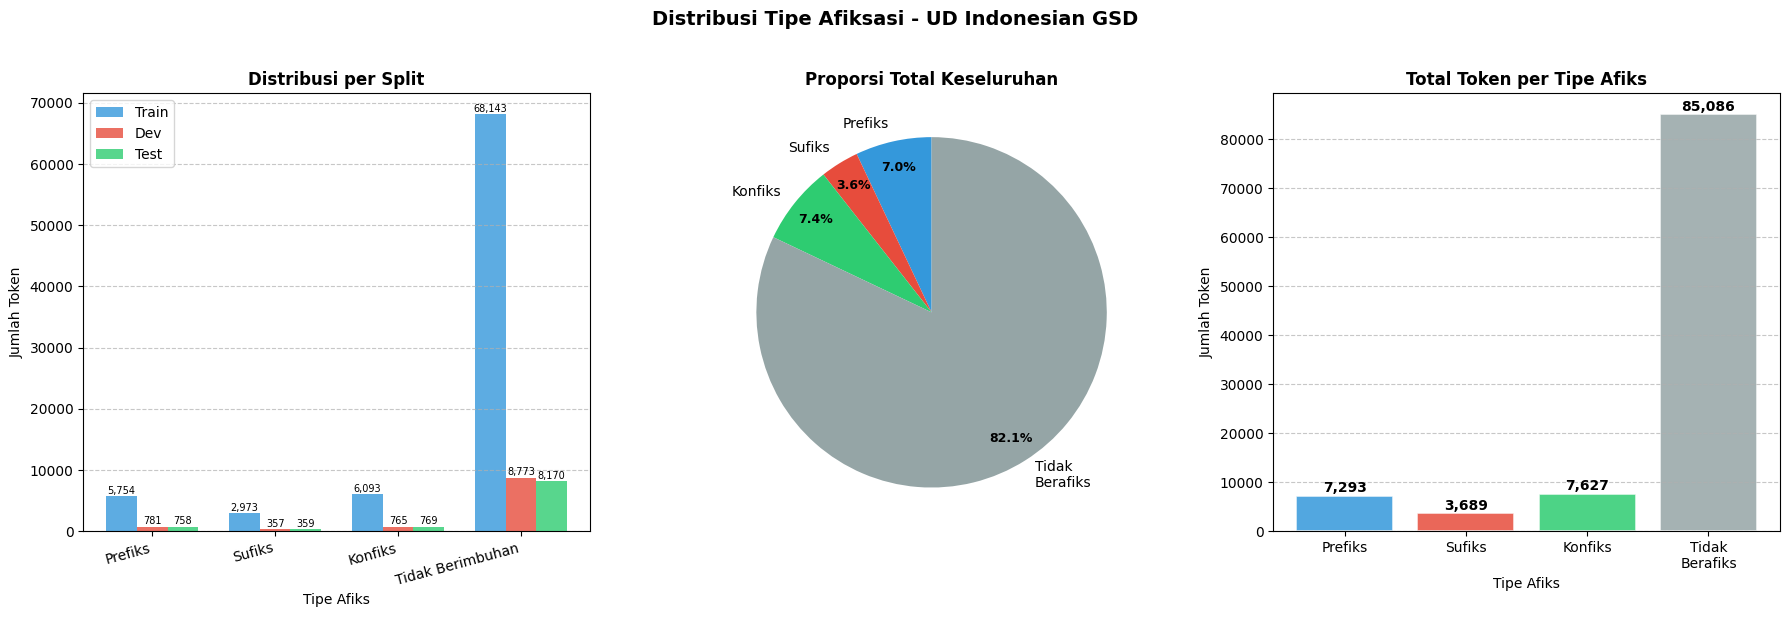

In [13]:
# =================================
# VISUALISASI DISTRIBUSI TIPE AFIKS
# =================================
# Memisahkan kembali df_raw_morph menjadi train, dev, dan test
df_train = df_raw_morph[df_raw_morph['sent_id'].str.contains('train', case=False, na=False)]
df_dev   = df_raw_morph[df_raw_morph['sent_id'].str.contains('dev', case=False, na=False)]
df_test  = df_raw_morph[df_raw_morph['sent_id'].str.contains('test', case=False, na=False)]

# Sesuaikan label dengan output fungsi ekstraksi kita
tipe_list = ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak Berimbuhan']
counts = {}

for tipe in tipe_list:
    c_train = len(df_train[df_train['tipe_afiks'] == tipe])
    c_dev   = len(df_dev[df_dev['tipe_afiks'] == tipe])
    c_test  = len(df_test[df_test['tipe_afiks'] == tipe])
    
    counts[tipe] = {
        'train': c_train,
        'dev'  : c_dev,
        'test' : c_test,
        'total': c_train + c_dev + c_test
    }

# Mapping warna yang konsisten
colors = {
    'Prefiks'         : '#3498db', # Biru
    'Sufiks'          : '#e74c3c', # Merah
    'Konfiks'         : '#2ecc71', # Hijau
    'Tidak Berimbuhan' : '#95a5a6'  # Abu-abu
}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribusi Tipe Afiksasi - UD Indonesian GSD',
             fontsize=14, fontweight='bold', y=1.02)


# PLOT 1: Grouped Bar Chart per Split
ax1    = axes[0]
x      = np.arange(len(tipe_list))
width  = 0.25

bars_train = ax1.bar(x - width, [counts[t]['train'] for t in tipe_list],
                     width, label='Train', color='#3498db', alpha=0.8)
bars_dev   = ax1.bar(x,         [counts[t]['dev']   for t in tipe_list],
                     width, label='Dev',   color='#e74c3c', alpha=0.8)
bars_test  = ax1.bar(x + width, [counts[t]['test']  for t in tipe_list],
                     width, label='Test',  color='#2ecc71', alpha=0.8)

ax1.set_title('Distribusi per Split', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tipe Afiks')
ax1.set_ylabel('Jumlah Token')
ax1.set_xticks(x)
ax1.set_xticklabels(['Prefiks', 'Sufiks', 'Konfiks', 'Tidak Berimbuhan'],
                     rotation=15, ha='right')
ax1.legend()
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

# Anotasi teks di atas bar Plot 1
for bars in [bars_train, bars_dev, bars_test]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, height + 50,
                     f'{int(height):,}', ha='center', va='bottom', fontsize=7)


# PLOT 2: Pie Chart Total
ax2        = axes[1]
totals     = [counts[t]['total'] for t in tipe_list]
labels     = ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak\nBerafiks'] # \n agar rapi
color_list = [colors[t] for t in tipe_list]

wedges, texts, autotexts = ax2.pie(
    totals,
    labels=labels,
    colors=color_list,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
)

# Pertebal font persentase di dalam pie
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

ax2.set_title('Proporsi Total Keseluruhan', fontsize=12, fontweight='bold')


# PLOT 3: Bar Chart Total per Tipe Afiks
ax3        = axes[2]
bar_colors = [colors[t] for t in tipe_list]
bars       = ax3.bar(
    ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak\nBerafiks'],
    totals,
    color=bar_colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

ax3.set_title('Total Token per Tipe Afiks', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tipe Afiks')
ax3.set_ylabel('Jumlah Token')
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

# Anotasi teks di atas bar Plot 3
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 100,
             f'{int(height):,}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 5. Simpan Data yang Sudah Diproses

In [14]:
# ============================================
# SIMPAN DATA KE CSV
# ============================================
BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Morfologi_Afiksasi"

# Pastikan direktori sudah ada, jika belum buat
os.makedirs(BASE_PROCESSED, exist_ok=True)

# Definisikan nama file
file_train = os.path.join(BASE_PROCESSED, "ud-indo-gsd_train_morph.csv")
file_dev   = os.path.join(BASE_PROCESSED, "ud-indo-gsd_dev_morph.csv")
file_test  = os.path.join(BASE_PROCESSED, "ud-indo-gsd_test_morph.csv")

# Ekspor ke CSV
df_train.to_csv(file_train, index=False, encoding='utf-8')
df_dev.to_csv(file_dev, index=False, encoding='utf-8')
df_test.to_csv(file_test, index=False, encoding='utf-8')

# Print status sesuai format yang diminta
print(f"✓ Train : {len(df_train)} token")
print(f"✓ Dev   : {len(df_dev)} token")
print(f"✓ Test  : {len(df_test)} token")
print(f"✓ Disimpan: ud-indo-gsd_train_morph.csv")
print(f"✓ Disimpan: ud-indo-gsd_dev_morph.csv")
print(f"✓ Disimpan: ud-indo-gsd_test_morph.csv\n")
print("Semua data berhasil disimpan! ✅")

✓ Train : 82963 token
✓ Dev   : 10676 token
✓ Test  : 10056 token
✓ Disimpan: ud-indo-gsd_train_morph.csv
✓ Disimpan: ud-indo-gsd_dev_morph.csv
✓ Disimpan: ud-indo-gsd_test_morph.csv

Semua data berhasil disimpan! ✅


## B. Negasi

### 1. Inisialisasi List untuk Menyimpan Data Negasi

In [15]:
# =====================================================
# INISIALISASI LIST, FILTER KALIMAT NEGASI & TANDA BACA
# =====================================================

raw_data_negation = [] 

for kalimat in data_gsd_all:
    # Periksa apakah kalimat ini mengandung minimal satu Kata Negasi
    ada_negasi = False
    for token in kalimat:
        if isinstance(token['id'], int) and token['feats'] and "'Polarity': 'Neg'" in str(token['feats']):
            ada_negasi = True
            break
            
    # Jika kalimat tidak memiliki Kata Negasi sama sekali, lewati (jangan dimasukkan ke raw_data)
    if not ada_negasi:
        continue
        
    teks = kalimat.metadata.get('text', '')
    sent_id = kalimat.metadata.get('sent_id', '')
    
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
            
        # Kecualikan tanda baca (PUNCT) sebelum pelabelan
        if token['upos'] == 'PUNCT':
            continue
            
        raw_data_negation.append({
            'sent_id'  : sent_id,
            'teks'     : teks,
            'token_id' : token['id'],
            'token'    : token['form'],
            'lemma'    : token['lemma'],
            'upos'     : token['upos'],
            'xpos'     : token['xpos'],
            'feats'    : str(token['feats']) if token['feats'] else '-',
            'head'     : token['head'],
            'deprel'   : token['deprel'],
            'misc'     : str(token['misc']) if token['misc'] else '-',
        })

df_raw_negation = pd.DataFrame(raw_data_negation)

### 2. Inisialisasi Fungsi Feature Extraction untuk Labeling Scope Negasi

In [16]:
# ==================================================================
# Inisialisasi Fungsi Feature Extraction untuk Labeling Scope Negasi
# ==================================================================

def ekstrak_label_negasi(df_sent):
    df_sent = df_sent.copy()
    
    # 1. Set default label
    df_sent['negasi_scope'] = 'Out_Scope'
    
    # 2. Deteksi Kata Negasi
    mask_negasi = df_sent['feats'].str.contains(r"'Polarity': 'Neg'", na=False)
    id_kata_negasi = df_sent.loc[mask_negasi, 'token_id'].tolist()
    
    if not id_kata_negasi:
        return df_sent
        
    # 3. Buat adjacency list (mapping head -> daftar token anak)
    children_map = defaultdict(list)
    for _, row in df_sent.iterrows():   # looping untuk membaca setiap kata (baris data) di dalam kalimat tersebut satu per satu dari awal sampai akhir.
        children_map[row['head']].append(row['token_id'])
        
    in_scope_ids = set()
    
    # 4. Telusuri tree untuk setiap Kata Negasi
    for neg_id in id_kata_negasi:
        head_idx = df_sent.loc[df_sent['token_id'] == neg_id, 'head'].values
        if len(head_idx) == 0:
            continue
        head_id = head_idx[0]
        
        in_scope_ids.add(head_id)
            
        # Cari semua keturunan (descendants) dari HEAD menggunakan BFS
        queue = [head_id]
        while queue:
            curr_node = queue.pop(0)
            anak_anak = children_map.get(curr_node, [])
            for anak in anak_anak:
                if anak not in in_scope_ids:
                    in_scope_ids.add(anak)
                    queue.append(anak)
                    
    # Pastikan Kata Negasi itu sendiri tidak dilabeli In_Scope
    in_scope_ids = in_scope_ids - set(id_kata_negasi)
    
    # 5. Terapkan label ke dalam dataframe
    df_sent.loc[df_sent['token_id'].isin(id_kata_negasi), 'negasi_scope'] = 'Kata Negasi'
    df_sent.loc[df_sent['token_id'].isin(in_scope_ids), 'negasi_scope'] = 'In_Scope'
    
    return df_sent

### 3. Implementasi Fungsi Feature Extraction untuk Labeling Scope Negasi

In [17]:
# ==================================================================
# Implementasi Feature Extraction Untuk Pelabelan Kolom Negasi Scope
# ==================================================================

df_list = []
for sent_id, df_sent in df_raw_negation.groupby('sent_id'):
    df_list.append(ekstrak_label_negasi(df_sent))

df_negasi_labeled = pd.concat(df_list, ignore_index=True)

print("🚨Status: Labeling Negasi Berdasarkan Dependency Tree - Berhasil✅")
print(f"Total baris setelah dilabeli: {len(df_negasi_labeled)}")

🚨Status: Labeling Negasi Berdasarkan Dependency Tree - Berhasil✅
Total baris setelah dilabeli: 11342


### 4. Table dan Visualisasi Hasil Labeling

In [18]:
# ==============================
# TABEL: DISTRIBUSI NEGASI SCOPE
# ==============================

# Memisahkan df_negasi_labeled menjadi train, dev, dan test
df_train_neg = df_negasi_labeled[df_negasi_labeled['sent_id'].str.contains('train', case=False, na=False)]
df_dev_neg   = df_negasi_labeled[df_negasi_labeled['sent_id'].str.contains('dev', case=False, na=False)]
df_test_neg  = df_negasi_labeled[df_negasi_labeled['sent_id'].str.contains('test', case=False, na=False)]

label_list = ['Out_Scope', 'In_Scope', 'Kata Negasi']
counts_neg = {}

for lbl in label_list:
    c_train = len(df_train_neg[df_train_neg['negasi_scope'] == lbl])
    c_dev   = len(df_dev_neg[df_dev_neg['negasi_scope'] == lbl])
    c_test  = len(df_test_neg[df_test_neg['negasi_scope'] == lbl])
    
    counts_neg[lbl] = {
        'train': c_train,
        'dev'  : c_dev,
        'test' : c_test,
        'total': c_train + c_dev + c_test
    }

colors_neg = {
    'Kata Negasi' : '#e74c3c', 
    'In_Scope'    : '#3498db', 
    'Out_Scope'   : '#95a5a6'  
}

print("\n=== TABEL: DISTRIBUSI LABEL NEGASI SCOPE ===")
df_tabel_neg = pd.DataFrame([
    {
        'NEGASI SCOPE': lbl,
        'JUMLAH': counts_neg[lbl]['total'],
        'PERSENTASE (%)': round((counts_neg[lbl]['total'] / len(df_negasi_labeled)) * 100, 2) if len(df_negasi_labeled) > 0 else 0
    }
    for lbl in label_list
])
display(df_tabel_neg)
print("Total Token (Hanya Kalimat Bernegasi & Non-Tanda Baca):", len(df_negasi_labeled))


=== TABEL: DISTRIBUSI LABEL NEGASI SCOPE ===


,NEGASI SCOPE,JUMLAH,PERSENTASE (%)
0,Out_Scope,6184,54.52
1,In_Scope,4615,40.69
2,Kata Negasi,543,4.79


Total Token (Hanya Kalimat Bernegasi & Non-Tanda Baca): 11342


In [19]:
# ================================================
# TABEL: SAMPLE HASIL EKSTRAKSI LABEL NEGASI SCOPE
# ================================================
print("\n=== TABEL: SAMPLE DATA HASIL LABELING ===")
sampel_tampil = df_negasi_labeled[df_negasi_labeled['negasi_scope'].isin(['Kata Negasi', 'In_Scope', 'Out_Scope'])].head(20)
display(sampel_tampil[['sent_id', 'token', 'token_id', 'head', 'feats', 'negasi_scope']])


=== TABEL: SAMPLE DATA HASIL LABELING ===


,sent_id,token,token_id,head,feats,negasi_scope
0,dev-s12,Spin,1,2,-,Out_Scope
1,dev-s12,beranalogi,2,0,"{'Number': 'Sing', 'Voice': 'Act'}",Out_Scope
2,dev-s12,dengan,3,4,-,Out_Scope
3,dev-s12,momentum,4,2,-,Out_Scope
4,dev-s12,sudut,5,4,{'Number': 'Sing'},Out_Scope
5,dev-s12,suatu,6,7,{'PronType': 'Ind'},Out_Scope
6,dev-s12,objek,7,5,{'Number': 'Sing'},Out_Scope
7,dev-s12,yang,8,9,{'PronType': 'Rel'},Out_Scope
8,dev-s12,berputar,9,7,"{'Number': 'Sing', 'Voice': 'Act'}",Out_Scope
9,dev-s12,pada,10,11,-,Out_Scope


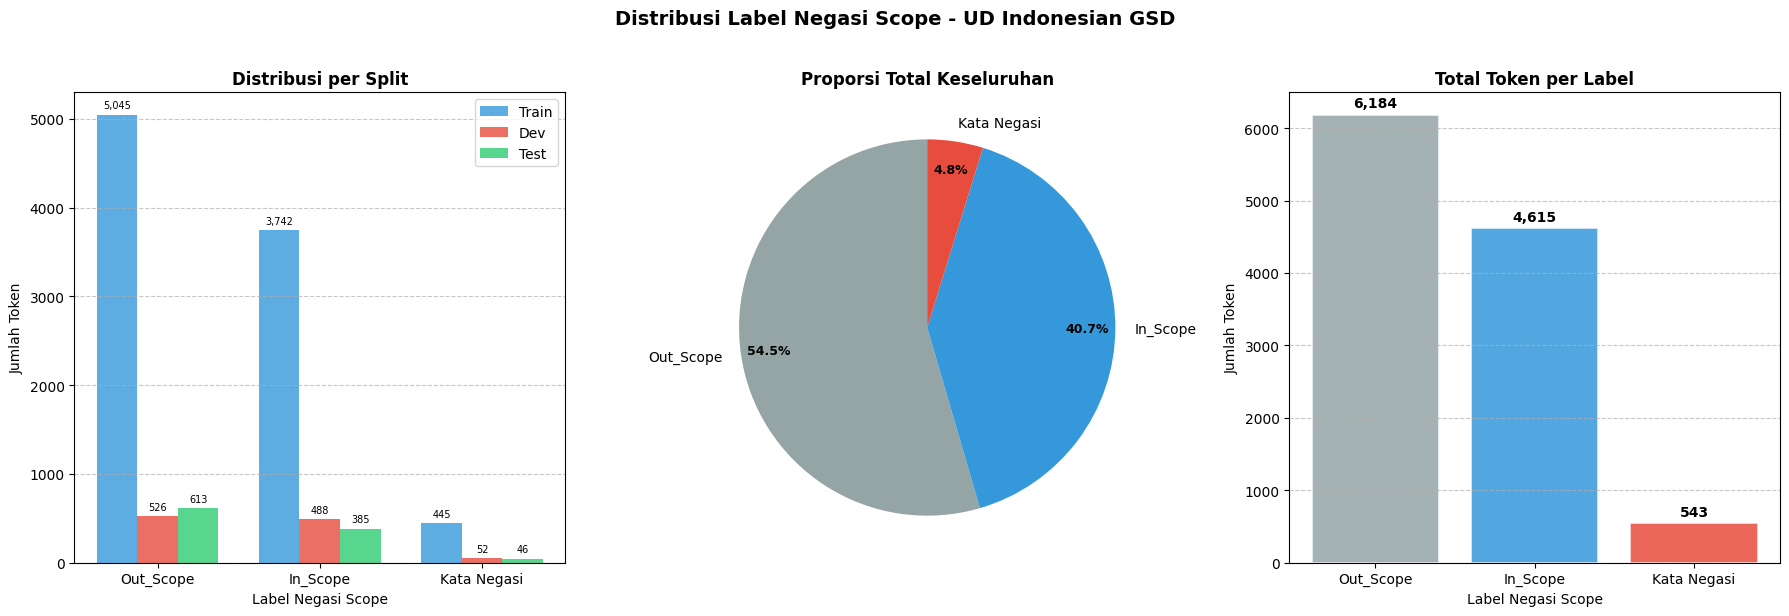

In [20]:
# =================================
# VISUALISASI DISTRIBUSI TIPE AFIKS
# =================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribusi Label Negasi Scope - UD Indonesian GSD', fontsize=14, fontweight='bold', y=1.02)

# PLOT 1
ax1 = axes[0]
x = np.arange(len(label_list))
width = 0.25

bars_train = ax1.bar(x - width, [counts_neg[l]['train'] for l in label_list], width, label='Train', color='#3498db', alpha=0.8)
bars_dev   = ax1.bar(x,         [counts_neg[l]['dev']   for l in label_list], width, label='Dev',   color='#e74c3c', alpha=0.8)
bars_test  = ax1.bar(x + width, [counts_neg[l]['test']  for l in label_list], width, label='Test',  color='#2ecc71', alpha=0.8)

ax1.set_title('Distribusi per Split', fontsize=12, fontweight='bold')
ax1.set_xlabel('Label Negasi Scope')
ax1.set_ylabel('Jumlah Token')
ax1.set_xticks(x)
ax1.set_xticklabels(label_list)
ax1.legend()
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

for bars in [bars_train, bars_dev, bars_test]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, height + (max([counts_neg[l]['train'] for l in label_list])*0.01), 
                     f'{int(height):,}', ha='center', va='bottom', fontsize=7)

# PLOT 2
ax2 = axes[1]
totals_neg = [counts_neg[l]['total'] for l in label_list]
color_list_neg = [colors_neg[l] for l in label_list]

# Handle kasus jika total 0 agar tidak error pie chartnya
if sum(totals_neg) > 0:
    wedges, texts, autotexts = ax2.pie(
        totals_neg, labels=label_list, colors=color_list_neg, autopct='%1.1f%%', startangle=90, pctdistance=0.85
    )
    for text in autotexts:
        text.set_fontsize(9)
        text.set_fontweight('bold')
ax2.set_title('Proporsi Total Keseluruhan', fontsize=12, fontweight='bold')

# PLOT 3
ax3 = axes[2]
bars_tot = ax3.bar(label_list, totals_neg, color=color_list_neg, alpha=0.85, edgecolor='white', linewidth=1.2)
ax3.set_title('Total Token per Label', fontsize=12, fontweight='bold')
ax3.set_xlabel('Label Negasi Scope')
ax3.set_ylabel('Jumlah Token')
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars_tot:
    height = bar.get_height()
    if height > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, height + (max(totals_neg)*0.01), 
                 f'{int(height):,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 5. Simpan Data yang Sudah Diproses

In [21]:
# =============================
# 5. SIMPAN DATA NEGASI KE CSV
# =============================
BASE_PROCESSED_NEG = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Negasi"
os.makedirs(BASE_PROCESSED_NEG, exist_ok=True)

file_train_neg = os.path.join(BASE_PROCESSED_NEG, "ud-indo-gsd_train_negation.csv")
file_dev_neg   = os.path.join(BASE_PROCESSED_NEG, "ud-indo-gsd_dev_negation.csv")
file_test_neg  = os.path.join(BASE_PROCESSED_NEG, "ud-indo-gsd_test_negation.csv")

df_train_neg.to_csv(file_train_neg, index=False, encoding='utf-8')
df_dev_neg.to_csv(file_dev_neg, index=False, encoding='utf-8')
df_test_neg.to_csv(file_test_neg, index=False, encoding='utf-8')

print(f"✓ Train : {len(df_train_neg)} token")
print(f"✓ Dev   : {len(df_dev_neg)} token")
print(f"✓ Test  : {len(df_test_neg)} token")
print("Semua data negasi scope yang sudah disaring berhasil disimpan! ✅")

✓ Train : 9232 token
✓ Dev   : 1066 token
✓ Test  : 1044 token
Semua data negasi scope yang sudah disaring berhasil disimpan! ✅


## C. Relasi Sintaksis

Pada probing task ini tidak diperlukan preprocessing data apapun, karena data pada UD-Indo-GSD bisa langsung digunakan.

### 1. Visualisasi Data

=== VISUALISASI DISTRIBUSI LABEL SINTAKSIS DAN SPLIT DATA ===



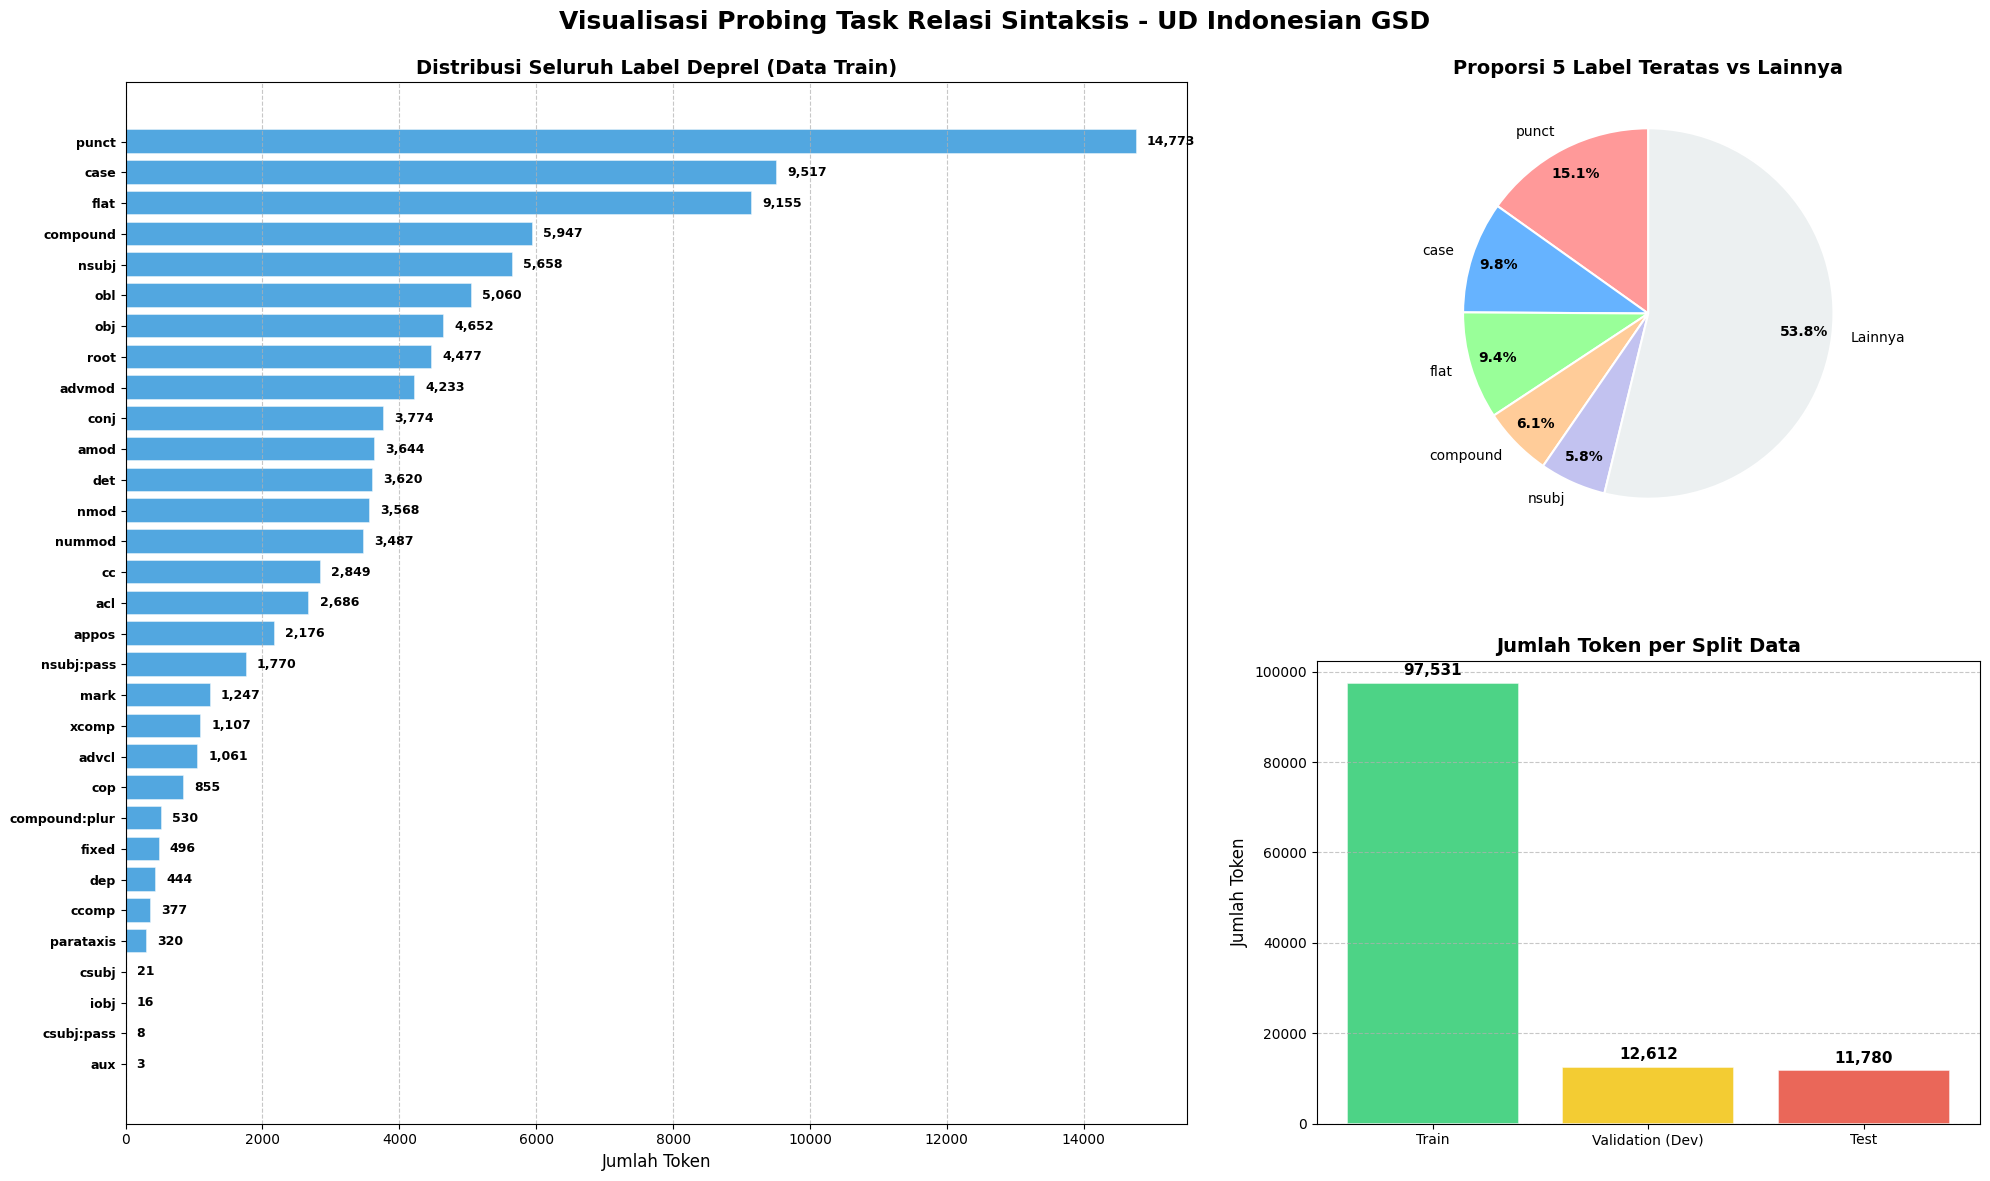

In [6]:
def extract_syntactic_data(conllu_data, split_name):
    rows = []
    for i, sentence in enumerate(conllu_data):
        sent_id = sentence.metadata.get("sent_id", f"{split_name}_{i+1}")
        # Ambil teks kalimat penuh dari metadata
        teks = sentence.metadata.get("text", "")
        
        for token in sentence:
            if not isinstance(token["id"], int):
                continue
            
            rows.append({
                "sent_id":  sent_id,
                "teks":     teks,                  # kalimat penuh
                "token":    token["form"],          # token asli
                "lemma":    token["lemma"],
                "upos":     token["upos"],
                "xpos":     token["xpos"],
                "feats":    token["feats"],         # dict atau None
                "head":     token["head"],
                "deprel":   token["deprel"],
                "misc":     token["misc"],          # dict atau None
                "token_id": token["id"],
            })
    return pd.DataFrame(rows)

# 1. Ekstrak data menjadi DataFrame
df_syn_train = extract_syntactic_data(data_gsd_train, "train")
df_syn_dev = extract_syntactic_data(data_gsd_dev, "dev")
df_syn_test = extract_syntactic_data(data_gsd_test, "test")

# ============================================
# VISUALISASI DISTRIBUSI LABEL & SPLIT DATA
# ============================================
print("=== VISUALISASI DISTRIBUSI LABEL SINTAKSIS DAN SPLIT DATA ===\n")

# Menghitung seluruh frekuensi label pada data train
deprel_counts = df_syn_train["deprel"].value_counts()

# Menyiapkan data untuk Pie Chart (Top 5 + Lainnya)
top_5 = deprel_counts.head(5)
others_count = deprel_counts.iloc[5:].sum()
pie_labels = top_5.index.tolist() + ['Lainnya']
pie_counts = top_5.values.tolist() + [others_count]

# Menyiapkan data untuk Bar Chart Split
split_labels = ['Train', 'Validation (Dev)', 'Test']
split_counts = [len(df_syn_train), len(df_syn_dev), len(df_syn_test)]

# Membuat Figure dan GridSpec
fig = plt.figure(figsize=(20, 12))
# Membuat grid 2 baris, 2 kolom dengan kolom kiri lebih lebar
gs = gridspec.GridSpec(2, 2, width_ratios=[1.6, 1], height_ratios=[1, 1])
fig.suptitle('Visualisasi Probing Task Relasi Sintaksis - UD Indonesian GSD', 
             fontsize=18, fontweight='bold')

# ---------------------------------------------
# Plot 1: Horizontal Bar Chart (Kiri, Full Height)
# ---------------------------------------------
ax1 = plt.subplot(gs[:, 0]) # Mengambil seluruh baris pada kolom 0
y_pos = range(len(deprel_counts))
bars1 = ax1.barh(y_pos, deprel_counts.values, color='#3498db', alpha=0.85, edgecolor='white', linewidth=1.2)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(deprel_counts.index, fontweight='bold', fontsize=9)
ax1.invert_yaxis()  # Label tertinggi di atas
ax1.set_title('Distribusi Seluruh Label Deprel (Data Train)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Jumlah Token', fontsize=12)
ax1.xaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + (max(deprel_counts.values)*0.01), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontweight='bold', fontsize=9)

# ---------------------------------------------
# Plot 2: Pie Chart (Kanan Atas)
# ---------------------------------------------
ax2 = plt.subplot(gs[0, 1]) # Baris 0, Kolom 1
colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ecf0f1']
wedges, texts, autotexts = ax2.pie(
    pie_counts, labels=pie_labels, colors=colors_pie[:len(pie_labels)],
    autopct='%1.1f%%', startangle=90, pctdistance=0.85,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
ax2.set_title('Proporsi 5 Label Teratas vs Lainnya', fontweight='bold', fontsize=14)

# ---------------------------------------------
# Plot 3: Vertical Bar Chart (Kanan Bawah)
# ---------------------------------------------
ax3 = plt.subplot(gs[1, 1]) # Baris 1, Kolom 1
colors_split = ['#2ecc71', '#f1c40f', '#e74c3c']
bars3 = ax3.bar(split_labels, split_counts, color=colors_split, alpha=0.85, edgecolor='white', linewidth=1.2)
ax3.set_title('Jumlah Token per Split Data', fontweight='bold', fontsize=14)
ax3.set_ylabel('Jumlah Token', fontsize=12)
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + (max(split_counts)*0.01), 
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92, wspace=0.15, hspace=0.25)
plt.show()

### 2. Simpan Data dalam File CSV

In [7]:
BASE_PROCESSED_SYNTACTIC = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Relasi_Sintaksis"
os.makedirs(BASE_PROCESSED_SYNTACTIC, exist_ok=True)

# Path lengkap untuk menyimpan file
train_path = os.path.join(BASE_PROCESSED_SYNTACTIC, "ud-indo-gsd_train_syntactic.csv")
dev_path = os.path.join(BASE_PROCESSED_SYNTACTIC, "ud-indo-gsd_dev_syntactic.csv")
test_path = os.path.join(BASE_PROCESSED_SYNTACTIC, "ud-indo-gsd_test_syntactic.csv")

# Menyimpan dataframe ke CSV tanpa index
df_syn_train.to_csv(train_path, index=False, encoding="utf-8")
df_syn_dev.to_csv(dev_path, index=False, encoding="utf-8")
df_syn_test.to_csv(test_path, index=False, encoding="utf-8")

print(f"✓ Train : {len(df_train_neg)} token")
print(f"✓ Dev   : {len(df_dev_neg)} token")
print(f"✓ Test  : {len(df_test_neg)} token")
print("Semua data negasi scope yang sudah disaring berhasil disimpan! ✅")

NameError: name 'df_train_neg' is not defined

## 4. POS Tagging

Pada probing task ini tidak diperlukan preprocessing data apapun, karena data pada POS Tagging IndoLEM bisa langsung digunakan.

### 1. Visualisasi Data

=== VISUALISASI DISTRIBUSI LABEL POS TAGGING DAN SPLIT DATA ===



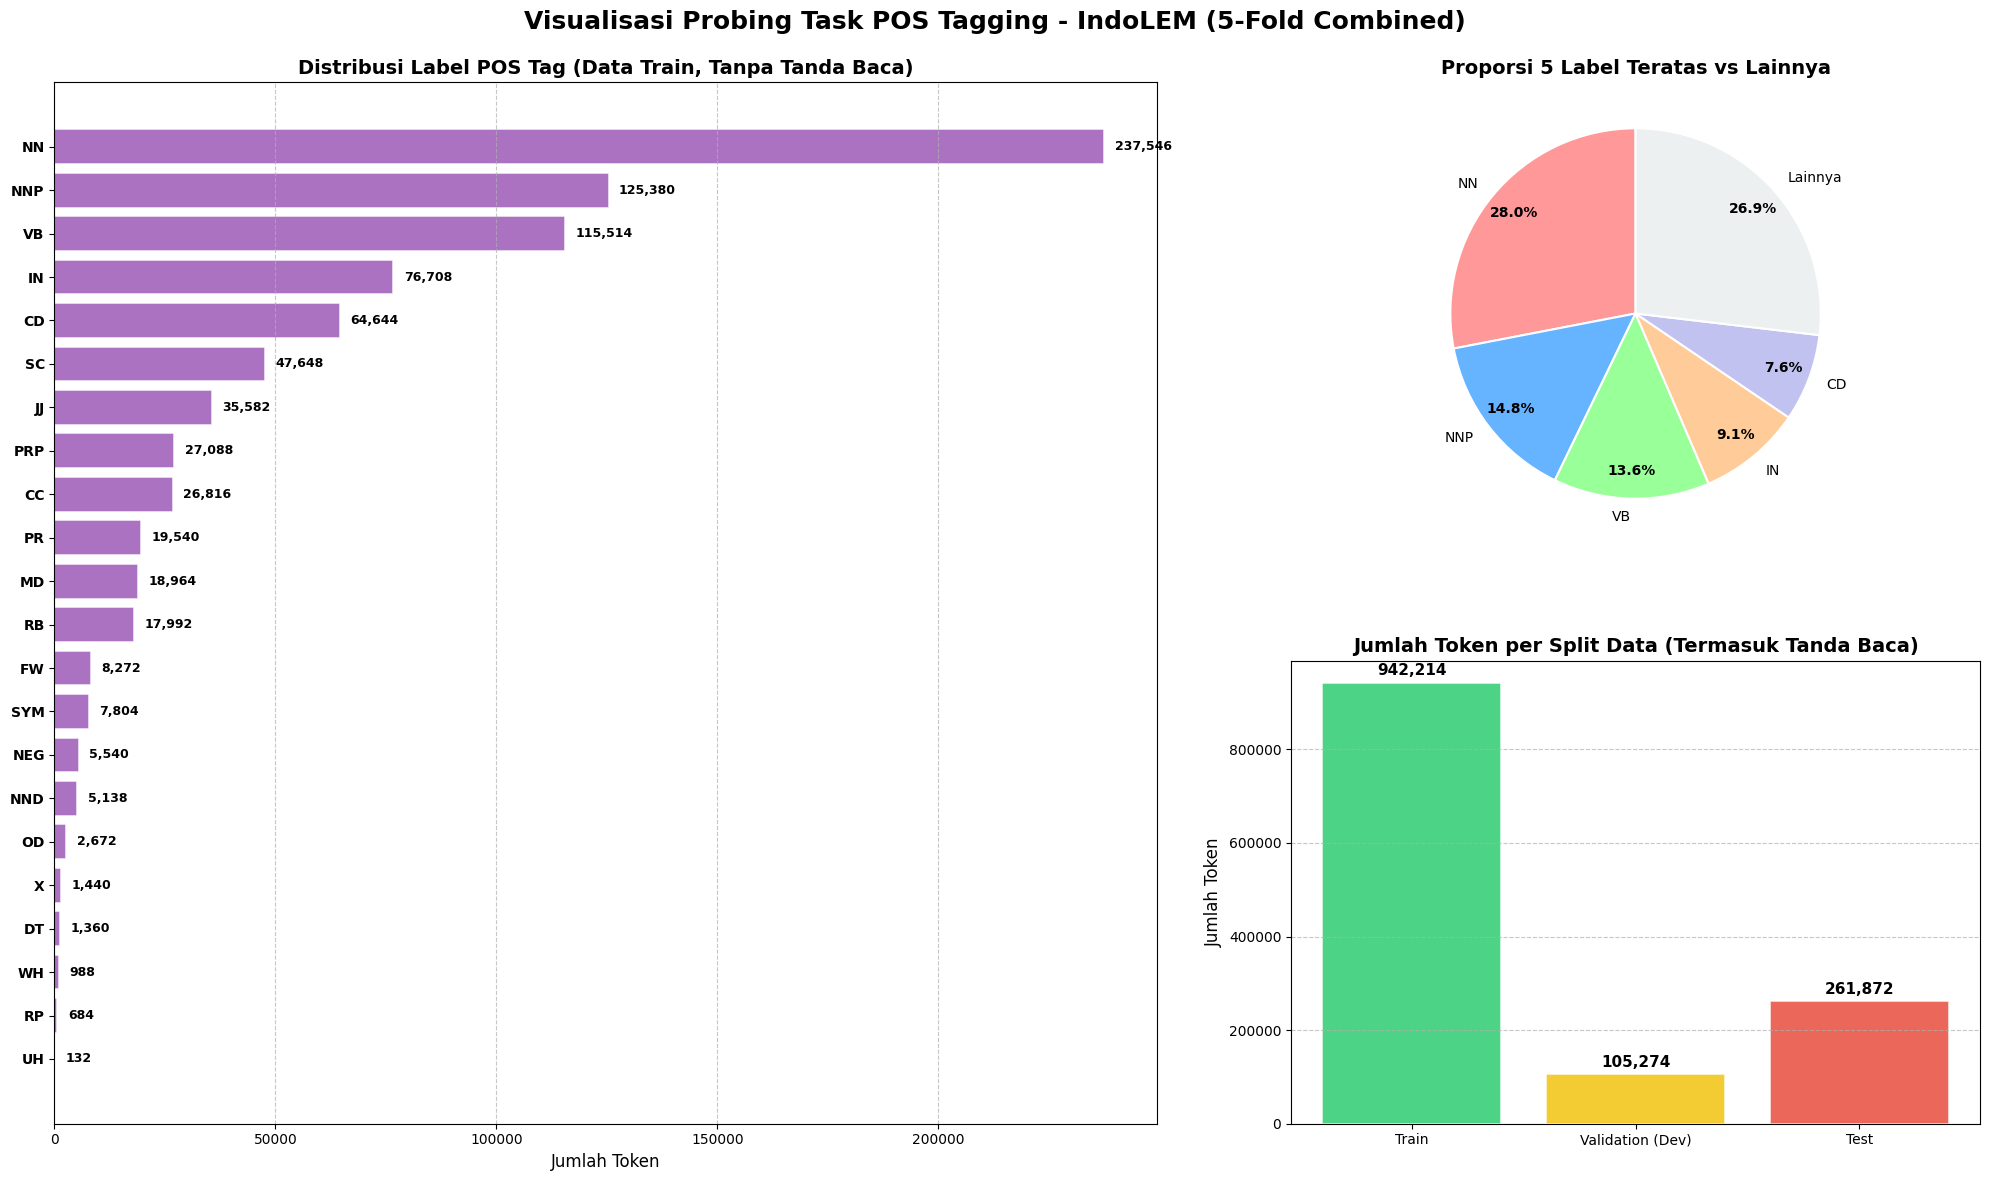

In [24]:
# ============================================
# FUNGSI EKSTRAKSI DATA POS TAGGING KE DATAFRAME
# ============================================
def extract_pos_data(sentences_list, split_name):
    rows = []
    sent_id_counter = 1
    
    for kalimat in sentences_list:
        lines = kalimat.split('\n')
        token_id = 1
        
        for line in lines:
            parts = line.split('\t')
            if len(parts) == 2:
                rows.append({
                    "sent_id": f"{split_name}_{sent_id_counter}",
                    "token_id": token_id,
                    "token": parts[0],
                    "pos_tag": parts[1]
                })
                token_id += 1
        sent_id_counter += 1
        
    return pd.DataFrame(rows)

# Ekstrak list kalimat menjadi DataFrame terpisah
df_pos_train_split = extract_pos_data(data_pos_train, "train")
df_pos_dev_split   = extract_pos_data(data_pos_dev, "dev")
df_pos_test_split  = extract_pos_data(data_pos_test, "test")

# ============================================
# VISUALISASI DISTRIBUSI LABEL & SPLIT DATA
# ============================================
print("=== VISUALISASI DISTRIBUSI LABEL POS TAGGING DAN SPLIT DATA ===\n")

# Menghitung frekuensi label pada data train (kecuali tanda baca 'Z' agar lebih representatif)
pos_counts = df_pos_train_split[df_pos_train_split['pos_tag'] != 'Z']["pos_tag"].value_counts()

# Menyiapkan data untuk Pie Chart (Top 5 + Lainnya)
top_5 = pos_counts.head(5)
others_count = pos_counts.iloc[5:].sum()
pie_labels = top_5.index.tolist() + ['Lainnya']
pie_counts = top_5.values.tolist() + [others_count]

# Menyiapkan data untuk Bar Chart Split
split_labels = ['Train', 'Validation (Dev)', 'Test']
split_counts = [len(df_pos_train_split), len(df_pos_dev_split), len(df_pos_test_split)]

# Membuat Figure dan GridSpec
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.6, 1], height_ratios=[1, 1])
fig.suptitle('Visualisasi Probing Task POS Tagging - IndoLEM (5-Fold Combined)', 
             fontsize=18, fontweight='bold')

# ---------------------
# Horizontal Bar Chart
# ---------------------
ax1 = plt.subplot(gs[:, 0]) 
y_pos = range(len(pos_counts))
bars1 = ax1.barh(y_pos, pos_counts.values, color='#9b59b6', alpha=0.85, edgecolor='white', linewidth=1.2)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(pos_counts.index, fontweight='bold', fontsize=10)
ax1.invert_yaxis()  
ax1.set_title('Distribusi Label POS Tag (Data Train, Tanpa Tanda Baca)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Jumlah Token', fontsize=12)
ax1.xaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + (max(pos_counts.values)*0.01), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontweight='bold', fontsize=9)

# ------------------
# Plot 2: Pie Chart 
# ------------------
ax2 = plt.subplot(gs[0, 1]) 
colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ecf0f1']
wedges, texts, autotexts = ax2.pie(
    pie_counts, labels=pie_labels, colors=colors_pie[:len(pie_labels)],
    autopct='%1.1f%%', startangle=90, pctdistance=0.85,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
ax2.set_title('Proporsi 5 Label Teratas vs Lainnya', fontweight='bold', fontsize=14)

# --------------------------
# Plot 3: Vertical Bar Chart 
# --------------------------
ax3 = plt.subplot(gs[1, 1]) 
colors_split = ['#2ecc71', '#f1c40f', '#e74c3c']
bars3 = ax3.bar(split_labels, split_counts, color=colors_split, alpha=0.85, edgecolor='white', linewidth=1.2)
ax3.set_title('Jumlah Token per Split Data (Termasuk Tanda Baca)', fontweight='bold', fontsize=14)
ax3.set_ylabel('Jumlah Token', fontsize=12)
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + (max(split_counts)*0.01), 
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92, wspace=0.15, hspace=0.25)
plt.show()

### 2. Simpan Data dalam File CSV

In [25]:
# ============================================
# MENYIMPAN DATASET POS TAGGING KE CSV
# ============================================

BASE_PROCESSED_POS = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\POS_Tagging"
os.makedirs(BASE_PROCESSED_POS, exist_ok=True)

# Path lengkap untuk menyimpan file
train_path_pos = os.path.join(BASE_PROCESSED_POS, "indolem_train_pos.csv")
dev_path_pos   = os.path.join(BASE_PROCESSED_POS, "indolem_dev_pos.csv")
test_path_pos  = os.path.join(BASE_PROCESSED_POS, "indolem_test_pos.csv")

# Menyimpan dataframe ke CSV tanpa index
df_pos_train_split.to_csv(train_path_pos, index=False, encoding="utf-8")
df_pos_dev_split.to_csv(dev_path_pos, index=False, encoding="utf-8")
df_pos_test_split.to_csv(test_path_pos, index=False, encoding="utf-8")

print("=== STATUS PENYIMPANAN DATA POS TAGGING ===")
print(f"✓ Train : {len(df_pos_train_split):,} token")
print(f"✓ Dev   : {len(df_pos_dev_split):,} token")
print(f"✓ Test  : {len(df_pos_test_split):,} token")

=== STATUS PENYIMPANAN DATA POS TAGGING ===
✓ Train : 942,214 token
✓ Dev   : 105,274 token
✓ Test  : 261,872 token
